<a href="https://colab.research.google.com/github/kauefs/DS/blob/%40/notebooks/GTFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<font color=#F0F0F0 size=8px font-family=Georgia>
<strong><ins>ƊⱭȾɅViƧi&#x1F9FF;Ƞ</ins>&trade;</strong></font>

![2025.03.01  ](https://img.shields.io/badge/2025.03.01-000000)

[![GitHub     ](https://img.shields.io/badge/-000000?logo=github&logoColor=FFFFFF)](https://github.com/kauefs/)
[![Medium     ](https://img.shields.io/badge/-000000?logo=medium&logoColor=FFFFFF)](https://medium.com/@kauefs)
[![LinkedIn   ](https://img.shields.io/badge/in-0077B5?logo=linkedin&logoColor=FFFFFF)](https://www.linkedin.com/in/kauefs/)
[![Python     ](https://img.shields.io/badge/3-646464?logo=python&logoColor=FFDE57&labelColor=4584B6)](https://www.python.org/)

[![License    ](https://img.shields.io/badge/Apache--2.0-D22128?style=flat&logo=apache&logoColor=CB2138&label=License&labelColor=6D6E71)](https://www.apache.org/licenses/LICENSE-2.0)

[![ƊⱭȾɅViƧi🧿Ƞ](https://img.shields.io/badge/ƊⱭȾɅViƧi&#x1F9FF;Ƞ&trade;-0065FF?style=plastic&label=&copy;2025&labelColor=0065FF)](https://datavision.one/)

Based on Work by [Maksym Kozlenko](https://max-coding.medium.com/how-to-process-gtfs-data-using-pandas-geopandas-4b34f2ad3273)

In [1]:
!date

Sat Mar  1 11:01:37 PM UTC 2025


In [2]:
# Installs:
%pip install -q contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 23.6 MB/s eta 0:00:00


In [3]:
# @title Libraries
import     pyproj,                       sys
import      numpy                   as    np
import     pandas                   as    pd
import  geopandas                   as   gpd
import    seaborn                   as   sns
import contextily                   as   ctx
import matplotlib.pyplot            as   plt
from   matplotlib.colors          import TwoSlopeNorm
from      shapely.geometry        import Point, LineString
from      zipfile                 import Path , ZipFile
from     datetime                 import datetime
# Configurations:
print('System Ready: Python –'  ,        sys.version)
%matplotlib  inline
%config      InlineBackend.figure_format='svg'
%precision      2
session_id   =  2
np.random.seed (2)
random_state =  2
pd.options.plotting.matplotlib.register_converters = True
pd.options.display.max_columns         =             None
plt.rcParams[  'figure.autolayout']    =             True
plt.rcParams[    'font.family']        =                                        'sans-serif'
sns.set_theme(context='notebook', style='whitegrid', palette='colorblind', font='sans-serif', font_scale=1.15, color_codes=True, rc={'grid.color':'1','grid.linestyle':':'})
FontT={'family': 'sans-serif'   ,'color':'#000000' ,  'size':13,     'fontweight':'semibold'}
FontY={'family': 'sans-serif'   ,'color':'#FF4500' ,  'size':10,     'fontweight': 'regular'}
FontX={'family': 'sans-serif'   ,'color':'#4CAF50' ,  'size':10,     'fontweight': 'regular'}

System Ready: Python – 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]


In [4]:
# @title      Data
# DownLoading Data:
!wget https://opendata.transport.nsw.gov.au/data/dataset/ded1949a-b7ae-43bd-9411-f55172290ffa/resource/5fc873b6-85d6-4c39-bdd5-6c3a102a703f/download/full_greater_sydney_gtfs_parent_tsn_1.zip

--2025-03-01 23:01:57--  https://opendata.transport.nsw.gov.au/data/dataset/ded1949a-b7ae-43bd-9411-f55172290ffa/resource/5fc873b6-85d6-4c39-bdd5-6c3a102a703f/download/full_greater_sydney_gtfs_parent_tsn_1.zip
Resolving opendata.transport.nsw.gov.au (opendata.transport.nsw.gov.au)... 13.35.186.80, 13.35.186.126, 13.35.186.97, ...
Connecting to opendata.transport.nsw.gov.au (opendata.transport.nsw.gov.au)|13.35.186.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 644546 (629K) [application/zip]
Saving to: ‘full_greater_sydney_gtfs_parent_tsn_1.zip’

full_greater_sydney 100%[===================>] 629.44K  1.58MB/s    in 0.4s    

2025-03-01 23:01:59 (1.58 MB/s) - ‘full_greater_sydney_gtfs_parent_tsn_1.zip’ saved [644546/644546]



In [5]:
# Loading Data Specifying Data Types for Each Column:
with ZipFile('full_greater_sydney_gtfs_parent_tsn_1.zip') as zip:
    shapes        =pd.read_csv(zip.open(        'shapes.txt'), dtype={    'shape_id'        :'str'  ,
                                                                       'shape_pt_lat'       :'float',
                                                                       'shape_pt_lon'       :'float',
                                                                       'shape_pt_sequence'  :'Int64',
                                                                     'shape_dist_traveled'  :'float'})
    routes        =pd.read_csv(zip.open(        'routes.txt'), dtype={    'route_id'        :'str'  ,
                                                                         'agency_id'        :'str'  ,
                                                                          'route_short_name':'str'  ,
                                                                          'route_long_name' :'str'  ,
                                                                          'route_desc'      :'str'  ,
                                                                          'route_type'      :'Int64',
                                                                          'route_color'     :'str'  ,
                                                                          'route_text_color':'str'  ,
                                                                          'exact_times'     :'bool' })
    trips         =pd.read_csv(zip.open(         'trips.txt'), dtype={    'route_id'        :'str'  ,
                                                                        'service_id'        :'str'  ,
                                                                           'trip_id'        :'str'  ,
                                                                          'shape_id'        :'str'  ,
                                                                           'trip_headsign'  :'str'  ,
                                                                      'direction_id'        :'str'  ,
                                                                          'block_id'        :'str'  ,
                                                                     'wheelchair_accessible':'str'  ,
                                                                          'route_direction' :'str'  ,
                                                                           'trip_note'      :'str'  ,
                                                                          'bikes_allowed'   :'str'  })
    calendar      =pd.read_csv(zip.open(      'calendar.txt'), dtype={  'service_id'        :'str'  ,
                                                                         'monday'           :'bool' ,
                                                                        'tuesday'           :'bool' ,
                                                                      'wednesday'           :'bool' ,
                                                                       'thursday'           :'bool' ,
                                                                         'friday'           :'bool' ,
                                                                       'saturday'           :'bool' ,
                                                                         'sunday'           :'bool' ,
                                                                          'start_date'      :'str'  ,
                                                                            'end_date'      :'str'  })
    calendar_dates=pd.read_csv(zip.open('calendar_dates.txt'), dtype={  'service_id'        :'str'  ,
                                                                                'date'      :'str'  ,
                                                                      'exception_type'      :'Int64'})
print('Data Loaded & Ready.')
# GeoPandas DataFrame Using World Geodetic System 1984 Ensemble:
shapes_geo=gpd.GeoDataFrame(shapes, geometry=gpd.points_from_xy(shapes.shape_pt_lon, shapes.shape_pt_lat)).set_crs(epsg=4326)

Data Loaded & Ready.


In [6]:
# @title Date
show_date_str='2023-07-06'
date         = datetime.strptime(show_date_str,'%Y-%m-%d')
date_string  = date    .strftime    ('%Y%m%d')
weekday      = date    .strftime('%A').lower()
services_for_day_1=calendar[(calendar[weekday])&(date_string >= calendar['start_date'])&(date_string <= calendar['end_date'])].service_id.to_numpy()
print(f'Scheduled for the day based on Calendar: {len(services_for_day_1)}')

Scheduled for the day based on Calendar: 55


In [7]:
# Exception Type:
# 1 - Service   added for the specified date;
# 2 - Service removed for the specified date.
calendar_dates[calendar_dates['date']=='20230706'].head(10)

,service_id,date,exception_type
330,TA+5L+1,20230706,2
911,TA+nD+1,20230706,2
974,TA+nF+1,20230706,2
1014,TA+o6100+1,20230706,2
1118,TA+r1139+1,20230706,2
1273,TA+r1420+1,20230706,2
1333,TA+r1420#1+1,20230706,2
1393,TA+r1422+1,20230706,2
1453,TA+r1425+1,20230706,2
1502,TA+r1428+1,20230706,2


In [8]:
# Finding Added & Removed Services for the Date:
services_added_for_day  =calendar_dates[(calendar_dates['date']==date_string)&(calendar_dates['exception_type']==1)].service_id.to_numpy()
services_removed_for_day=calendar_dates[(calendar_dates['date']==date_string)&(calendar_dates['exception_type']==2)].service_id.to_numpy()
print(f'Services   added using Calendar Dates:  {len(services_added_for_day  )}')
print(f'Services removed using Calendar Dates: {len(services_removed_for_day)}')
# Final List of Services Running on the Date:
services_for_day_2=np.concatenate([services_for_day_1, services_added_for_day] )
services_for_day  =np.setdiff1d   (services_for_day_2, services_removed_for_day)
print(f'Final Services for the Day:            {len(services_for_day)}')

Services   added using Calendar Dates:  0
Services removed using Calendar Dates: 45
Final Services for the Day:            10


In [9]:
shapes['shape_id'].unique()

array(['9-F10-sj2-1.1.R', '9-F10-sj2-1.2.H', '9-F10-sj2-1.3.H',
       '9-F10-sj2-1.4.H', '9-F1-sj2-1.1.R', '9-F1-sj2-1.2.R',
       '9-F1-sj2-1.3.H', '9-F1-sj2-1.4.H', '9-F2-sj2-1.1.R',
       '9-F2-sj2-1.10.H', '9-F2-sj2-1.11.H', '9-F2-sj2-1.12.H',
       '9-F2-sj2-1.13.H', '9-F2-sj2-1.14.H', '9-F2-sj2-1.2.R',
       '9-F2-sj2-1.3.R', '9-F2-sj2-1.4.R', '9-F2-sj2-1.5.R',
       '9-F2-sj2-1.6.R', '9-F2-sj2-1.7.R', '9-F2-sj2-1.8.R',
       '9-F2-sj2-1.9.R', '9-F3-sj2-1.1.R', '9-F3-sj2-1.10.R',
       '9-F3-sj2-1.11.R', '9-F3-sj2-1.12.R', '9-F3-sj2-1.13.R',
       '9-F3-sj2-1.14.R', '9-F3-sj2-1.15.R', '9-F3-sj2-1.16.R',
       '9-F3-sj2-1.17.R', '9-F3-sj2-1.18.R', '9-F3-sj2-1.19.R',
       '9-F3-sj2-1.2.R', '9-F3-sj2-1.20.R', '9-F3-sj2-1.21.R',
       '9-F3-sj2-1.22.R', '9-F3-sj2-1.23.R', '9-F3-sj2-1.24.R',
       '9-F3-sj2-1.25.R', '9-F3-sj2-1.26.R', '9-F3-sj2-1.27.R',
       '9-F3-sj2-1.28.R', '9-F3-sj2-1.29.R', '9-F3-sj2-1.3.R',
       '9-F3-sj2-1.30.R', '9-F3-sj2-1.31.R', '9-F3-sj2-1

In [10]:
routes['route_long_name'].unique()

array(['F10 Blackwattle Bay', 'F1 Manly', 'F2 Taronga Zoo',
       'F3 Parramatta River', 'F4 Pyrmont Bay', 'F5 Neutral Bay',
       'F6 Mosman Bay', 'F7 Double Bay', 'F8 Cockatoo Island',
       'F9 Watsons Bay'], dtype=object)

In [11]:
# Getting Each Route Segment with Start & End Coordinates & Sequence Along the Shape:
shapes[shapes['shape_id']=='9-F1-sj2-1.1.R']#.head(10)

,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
173,9-F1-sj2-1.1.R,-33.800446,151.283672,1,0.00
174,9-F1-sj2-1.1.R,-33.802063,151.282511,2,209.43
175,9-F1-sj2-1.1.R,-33.802999,151.281876,3,328.92
176,9-F1-sj2-1.1.R,-33.803511,151.281606,4,391.09
177,9-F1-sj2-1.1.R,-33.804231,151.281253,5,477.56
178,9-F1-sj2-1.1.R,-33.804969,151.280955,6,564.10
179,9-F1-sj2-1.1.R,-33.805691,151.280721,7,647.19
180,9-F1-sj2-1.1.R,-33.806323,151.280580,8,718.73
181,9-F1-sj2-1.1.R,-33.823995,151.278150,9,2696.48
182,9-F1-sj2-1.1.R,-33.825307,151.277890,10,2844.33


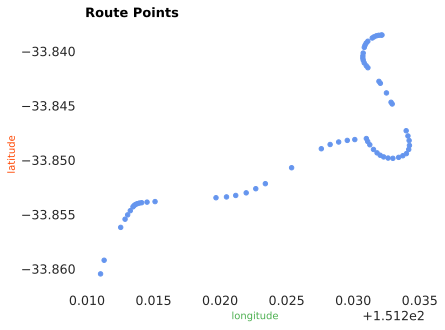

In [12]:
# @title Route Points
# Plotting Route Points for One Shape ID:
shapes[shapes['shape_id']=='9-F6-sj2-1.10.H'].plot.scatter(x='shape_pt_lon', y='shape_pt_lat', color='#6595EE')
plt.title    ('Route Points', fontdict=FontT , loc= 'left')
plt.ylabel   ('latitude'    , fontdict=FontY)
plt.xlabel   ('longitude'   , fontdict=FontX)
plt.box(False)
plt.show(    )

In [13]:
'''
In order to convert sequence of points into set of straight lines they need to be converted into numpy array of points and to roll it (shift it) by one position,
so point with sequence ID 1 becomes staring point and point with sequence ID 2 end point.
Segment with end point sequence equal 1 should be removed, since it's stating point contains point from another route.
'''
coords  =shapes[['shape_pt_lat',   'shape_pt_lon','shape_pt_sequence']]
coords_roll_1=np.roll(coords, 1, axis=0)
segments=pd.DataFrame(np.concatenate([coords_roll_1, coords], axis=1), columns=['start_lat','start_lng','start_seq','end_lat','end_lng','end_seq'])
segments_df=shapes[['shape_id']].join  (segments)
segments_df=segments_df[segments_df     .end_seq != 1]
segments_df=segments_df.drop(columns=  ['end_seq']).rename(            columns={                        'start_seq':'seq'})
segments_df

,shape_id,start_lat,start_lng,seq,end_lat,end_lng
1,9-F10-sj2-1.1.R,-33.871383,151.185238,1,-33.871382,151.185282
2,9-F10-sj2-1.1.R,-33.871382,151.185282,2,-33.871044,151.18557
3,9-F10-sj2-1.1.R,-33.871044,151.18557,3,-33.871,151.185586
4,9-F10-sj2-1.1.R,-33.871,151.185586,4,-33.870936,151.185581
5,9-F10-sj2-1.1.R,-33.870936,151.185581,5,-33.870458,151.18543
...,...,...,...,...,...,...
34734,9-F9-sj2-1.9.R,-33.855222,151.214949,57,-33.855301,151.214723
34735,9-F9-sj2-1.9.R,-33.855301,151.214723,58,-33.855431,151.214539
34736,9-F9-sj2-1.9.R,-33.855431,151.214539,59,-33.856935,151.213371
34737,9-F9-sj2-1.9.R,-33.856935,151.213371,60,-33.859209,151.211289


In [14]:
# Total Count of Trips Along Route:
day_trips       =    trips[ trips['service_id'].isin(services_for_day    )]
sydney_route_ids=   routes[routes['route_desc']  == 'Sydney Ferries Network'].route_id.unique()
shape_day_trips =day_trips[  day_trips.route_id.isin(sydney_route_ids)].groupby(by='shape_id').size().to_frame('day_trips')
shape_day_trips

,day_trips
shape_id,
9-F1-sj2-1.1.R,52
9-F1-sj2-1.2.R,5
9-F1-sj2-1.3.H,52
9-F1-sj2-1.4.H,5
9-F10-sj2-1.1.R,25
...,...
9-F9-sj2-1.4.R,1
9-F9-sj2-1.5.R,1
9-F9-sj2-1.6.R,7


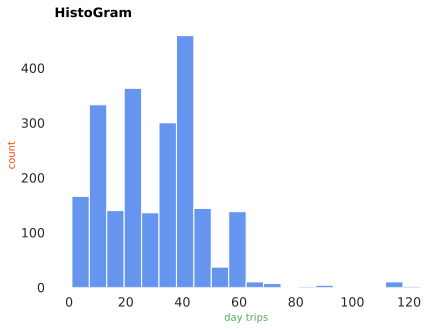

In [15]:
# @title HistoGram
# Merging with List of Segments:
shape_segments_day_trips=pd.merge(segments_df, shape_day_trips, left_on='shape_id' , right_index=True)
# Trip on Each Segment per Day:
shape_segments_day_trips=pd.merge(segments_df, shape_day_trips, left_on='shape_id' , right_index=True)
segment_day_trips = shape_segments_day_trips.groupby(by=['start_lat',   'start_lng',  'end_lat' ,'end_lng']).sum('day_trips').reset_index()
# Plot:
segment_day_trips['day_trips'].hist(bins=20, color='#6595EE')
plt.title        ('HistoGram' ,fontdict=FontT, loc=   'left')
plt.ylabel       ('count'     ,fontdict=FontY)
plt.xlabel       ('day trips' ,fontdict=FontX)
plt.box    (False)
plt.show   (     )

In [16]:
segment_day_trips

,start_lat,start_lng,end_lat,end_lng,day_trips
0,-33.872991,151.242606,-33.871354,151.242974,20
1,-33.871383,151.185238,-33.871382,151.185282,25
2,-33.871382,151.185282,-33.871383,151.185238,25
3,-33.871382,151.185282,-33.871044,151.185570,25
4,-33.871354,151.242974,-33.872991,151.242606,20
...,...,...,...,...,...
2245,-33.802999,151.281876,-33.803511,151.281606,57
2246,-33.802999,151.281876,-33.802063,151.282511,57
2247,-33.802063,151.282511,-33.802999,151.281876,57
2248,-33.802063,151.282511,-33.800446,151.283672,57


In [17]:
# LineString Geometry for Segment & GeoDataFrame:
def get_line_string(row):
    start=Point(row.start_lng, row.start_lat)
    end  =Point(row.end_lng  , row.end_lat)
    line =LineString([start  , end])
    row['geometry'] = line
    return row
segment_day_trips_gpd=gpd.GeoDataFrame(segment_day_trips.apply(get_line_string, axis=1)).set_crs(epsg=4326)

In [18]:
# Slope Normalization:
vmin   =segment_day_trips_gpd['day_trips'].min     (   )
vmax   =segment_day_trips_gpd['day_trips'].quantile(.95)
vcenter=segment_day_trips_gpd['day_trips'].mean    (   )
norm   =TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
# Bounding Box to Greater Sydney Area:
def limit_to_bounding_box(gdf, bounding_box): return gdf.cx[bounding_box['west']:bounding_box['east'],bounding_box['south']:bounding_box['north']]
# Greater Sydney bounding box
sydney_bb={'north':-33.65,
           'south':-34.10,
           'west' :150.60,
           'east' :151.40}

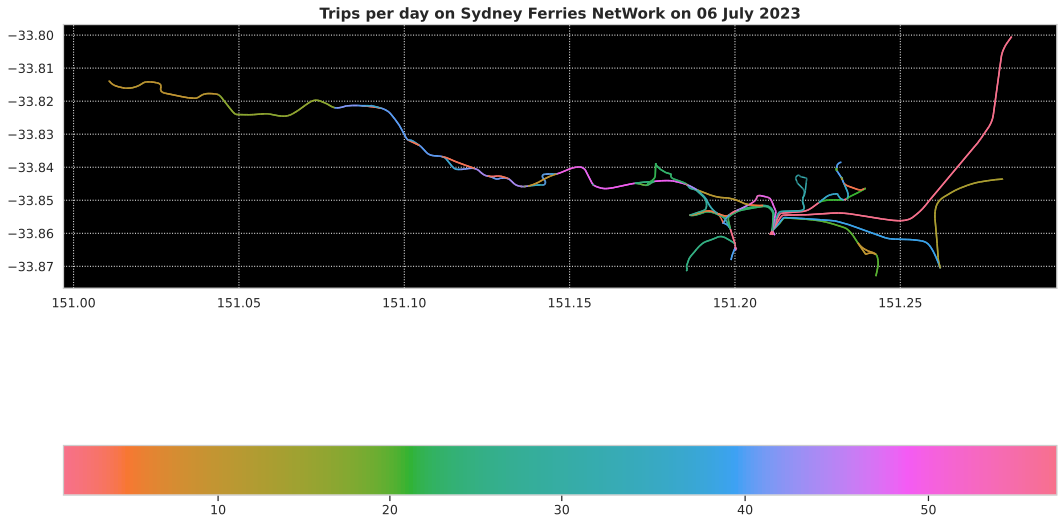

In [19]:
# @title NetWork Map Visualization
# GeoPandas Plot:
fig=plt.figure(figsize=(15,15),tight_layout=True)
ax =plt.axes( )
ax.set(facecolor='#000000')
cmap=sns.color_palette('husl' , as_cmap=True)
sydney_segment_day_trips_gpd=limit_to_bounding_box(segment_day_trips_gpd  ,   sydney_bb)
sydney_segment_day_trips_gpd.plot( ax=ax, cmap=cmap,column='day_trips'    ,   legend=True,       norm= norm, aspect=1, legend_kwds={'location':'bottom'})#,'shrink':.5
ax.set_title(f'Trips per day on Sydney Ferries NetWork on {date:%d %B %Y}', fontsize=15  , fontweight='bold'         )
plt.savefig ( 'SydNeyFerriesNetWork.png')
plt.show(   )
# Saving to File:
segment_day_trips_gpd[['day_trips','geometry']].to_csv('SydneyFerriesNetWorkSegments.csv.zip', compression='zip', index=False)